In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import os
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Классы CIFAR-10
# Соответствие цифровых лейблов (0-9) названиям классов
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Статистики для нормализации CIFAR-10 
# mean: среднее значение интенсивности пикселей для каждого канала (R, G, B)
# std: стандартное отклонение для каждого канала
# Эти значения используются, чтобы привести данные к нулевому среднему и единичной дисперсии,
# что ускоряет сходимость нейросети.
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

# Трансформации для обучения 
transform_train_base = transforms.Compose([
    transforms.Resize((32, 32)), # Приведение к единому размеру (для CIFAR-10 это избыточно, т.к. они уже 32x32, но полезно для унификации)
    transforms.ToTensor(),       # Конвертация PIL-изображения в тензор PyTorch  и масштабирование значений [0, 255] -> [0.0, 1.0]
    transforms.Normalize(mean, std) # Нормализация тензора по формуле: (img - mean) / std
])

# Трансформации для валидации и теста (только детерминированные)
# Здесь не используется аугментация (случайные повороты, кропы), чтобы оценка была объективной
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Загрузка датасета
# root='./data': папка для сохранения данных
# train=True: загружаем обучающую выборку (50,000 изображений)
# download=True: автоматически скачать, если файлов нет в папке
# transform: применяем подготовленные трансформации к каждому изображению при загрузке
trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                             download=True, transform=transform_train_base)
# train=False: загружаем тестовую выборку (10,000 изображений)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                       download=True, transform=transform_test)

# Разбиение train на train/val (80% train, 20% val от обучающей выборки)
# Всего 50,000 train. 40,000 train, 10,000 val. Test остается 10,000.
num_train = len(trainset_full) # Получаем полное количество элементов (50000)
indices = list(range(num_train)) # Создаем список индексов [0, 1, ..., 49999]
split = int(np.floor(0.8 * num_train)) # Вычисляем границу раздела (40000)

train_indices = indices[:split] # Индексы для новой обучающей выборки (0-39999)
val_indices = indices[split:]   # Индексы для валидационной выборки (40000-49999)

# Subset создает подмножество датасета на основе переданных индексов
# Данные физически не копируются, просто меняется доступ к ним
trainset = Subset(trainset_full, train_indices)
valset = Subset(trainset_full, val_indices)

# DataLoader
batch_size = 64 # Количество изображений, обрабатываемых за один шаг градиентного спуска

# trainloader: 
# shuffle=True: перемешивает данные каждый эпизод (важно для обучения, чтобы модель не запомнила порядок)
# num_workers=2: количество subprocess'ов для загрузки данных (ускоряет подачу данных на GPU)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

# valloader и testloader:
# shuffle=False: перемешивание не нужно, важно проверять данные в стабильном порядке
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# Вывод размеров для проверки корректности разбиения
print(f"Train size: {len(trainset)}, Val size: {len(valset)}, Test size: {len(testset)}")

/Users/dmitry/Desktop/BSUIR/IAD/lab_1/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train size: 40000, Val size: 10000, Test size: 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7091274..1.8768656].


car   frog  dog   car   ship  horse dog   plane horse frog  deer  bird  plane horse bird  cat   cat   plane cat   dog   bird  frog  frog  cat   car   horse ship  bird  truck truck cat   plane horse car   plane dog   frog  frog  truck plane horse car   deer  horse frog  horse truck plane bird  dog   dog   car   frog  plane cat   car   plane deer  truck deer  deer  horse cat   bird 


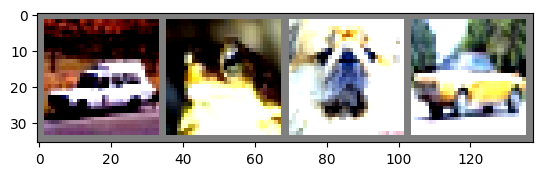

In [3]:
def imshow(img):
    img = img / 2 + 0.5    
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)

print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))
imshow(torchvision.utils.make_grid(images[:4]))

In [4]:
class SimpleCNN(nn.Module):
    # Наследование от nn.Module обязательно для всех моделей в PyTorch
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__() # Инициализация родительского класса
        
        # Блок 1: Conv -> BN -> ReLU -> Pool
        # in_channels=3: Входные каналы (RGB изображение)
        # out_channels=32: Количество фильтров (карт признаков), которые выучит слой
        # kernel_size=3: Размер сверточного окна 3x3
        # padding=1: Добавляет рамку из нулей, чтобы размер выхода совпадал с размером входа (при kernel=3)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Нормализация по 32 каналам (ускоряет сходимость)
        self.relu1 = nn.ReLU()        # Функция активации (вносит нелинейность)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Уменьшает размер карты в 2 раза (32x32 -> 16x16)
        
        # Блок 2: Conv -> BN -> ReLU -> Pool
        # Входные каналы теперь 32 (выход предыдущего слоя)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Уменьшает размер карты еще в 2 раза (16x16 -> 8x8)
        
        # Dropout в сверточной части (отключает случайные каналы целиком)
        # p=0.3: Вероятность обнуления элемента во время обучения
        self.dropout = nn.Dropout2d(p=0.3) 
        
        # Полносвязные слои (Classifier)
        # Расчет размера входа для Linear:
        # Начало: 32x32. После pool1: 16x16. После pool2: 8x8.
        # Глубина (каналов): 64.
        # Итого вектор: 64 * 8 * 8 = 4096 элементов
        self.fc1 = nn.Linear(64 * 8 * 8, 128) # Проекция в пространство размерности 128
        self.relu3 = nn.ReLU()
        self.dropout_fc = nn.Dropout(p=0.5)   # Обычный Dropout для вектора перед финальным слоем
        
        self.fc2 = nn.Linear(128, num_classes) # Выходной слой (128 -> 10 классов)
        
    def forward(self, x):
        # Прямой проход (Forward Pass)
        # Блок 1
        x = self.conv1(x)  # Свертка
        x = self.bn1(x) # Нормализация
        x = self.relu1(x) # Активация
        x = self.pool1(x) # Пулинг
        
        # Блок 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Dropout (применяется только во время обучения model.train())
        x = self.dropout(x)
        
        # Flatten (Превращение 3D тензора [Batch, 64, 8, 8] в 2D [Batch, 4096])
        # -1 означает, что размер батча определяется автоматически
        x = x.view(-1, 64 * 8 * 8)
        
        # Classifier
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout_fc(x)
        x = self.fc2(x)
        
        return x # Возвращает логиты (сырые оценки для каждого класса)

# Перенос модели на устройство (CUDA или CPU)
# Переменная device должна быть определена ранее, например: device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN(num_classes=10).to(device)

# Критерий и оптимизатор
# CrossEntropyLoss подходит для многоклассовой классификации (ожидает индексы классов, а не one-hot)
criterion = nn.CrossEntropyLoss()

# Adam - адаптивный оптимизатор
# model.parameters(): передаем все обучаемые параметры модели
# lr=0.001: скорость обучения (learning rate)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Вывод архитектуры модели для проверки слоев и размеров
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout2d(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    """
    Функция обучения модели на одной эпохе
    
    Параметры:
    - model: нейросеть для обучения
    - loader: DataLoader с обучающими данными (trainloader)
    - optimizer: оптимизатор (например, Adam) для обновления весов
    - criterion: функция потерь (например, CrossEntropyLoss)
    - device: устройство для вычислений (cuda/cpu)
    
    Возвращает:
    - epoch_loss: средняя потеря за эпоху
    """
    
    # Переключаем модель в режим обучения
    # Включает Dropout, BatchNorm в режиме обучения
    model.train()
    
    running_loss = 0.0  # Накопитель для суммы потерь за эпоху
    
    # Проход по всем батчам датасета
    for inputs, labels in loader:
        # Перенос данных на устройство (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Обнуление градиентов перед новым шагом
        # По умолчанию PyTorch накапливает градиенты, поэтому нужно сбрасывать
        optimizer.zero_grad()
        
        # Прямой проход (Forward Pass)
        # Модель выдаёт предсказания (логиты) для входных изображений
        outputs = model(inputs)
        
        # Вычисление функции потерь
        # Сравнивает предсказания модели с истинными лейблами
        loss = criterion(outputs, labels)
        
        # Обратный проход (Backward Pass)
        # Вычисляет градиенты всех параметров модели по функции потерь
        loss.backward() # Вычисление градиентов
        
        # Шаг оптимизатора
        # Обновляет веса модели на основе вычисленных градиентов
        optimizer.step()
        
        # Накопление потери для расчёта средней по эпохе
        # loss.item() - скалярное значение потери для текущего батча
        # inputs.size(0) - размер текущего батча (учитываем, что последний батч может быть меньше)
        running_loss += loss.item() * inputs.size(0)
        
    # Вычисление средней потери за эпоху
    # Делим общую сумму потерь на количество примеров в датасете
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def evaluate(model, loader, criterion, device):
    """
    Функция оценки модели на валидации/тесте
    
    Параметры:
    - model: нейросеть для оценки
    - loader: DataLoader с данными для оценки (valloader/testloader)
    - criterion: функция потерь для расчёта loss
    - device: устройство для вычислений (cuda/cpu)
    
    Возвращает:
    - epoch_loss: средняя потеря за эпоху
    - epoch_acc: точность классификации в процентах
    """
    
    # Переключаем модель в режим оценки
    # Отключает Dropout, BatchNorm использует скользящую статистику
    model.eval()
    
    running_loss = 0.0  # Накопитель для суммы потерь
    correct = 0         # Счётчик правильных предсказаний
    total = 0           # Счётчик всех примеров
    
    # Контекстный менеджер для отключения вычисления градиентов
    # Экономит память и ускоряет вычисления (градиенты не нужны при оценке)
    with torch.no_grad():
        for inputs, labels in loader:
            # Перенос данных на устройство
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Прямой проход (без вычисления градиентов)
            outputs = model(inputs)
            
            # Вычисление функции потерь
            loss = criterion(outputs, labels)
            
            # Накопление потери
            running_loss += loss.item() * inputs.size(0)
            
            # Получение предсказанных классов
            # torch.max(outputs.data, 1) возвращает (макс_значение, индекс_максимума)
            # dim=1 означает поиск максимума по классам (вторая размерность тензора)
            _, predicted = torch.max(outputs.data, 1)
            
            # Обновление счётчиков
            total += labels.size(0)  # Количество примеров в текущем батче
            correct += (predicted == labels).sum().item()  # Количество правильных предсказаний
            
    # Вычисление средней потери за эпоху
    epoch_loss = running_loss / len(loader.dataset)
    
    # Вычисление точности в процентах
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

In [6]:
# Количество эпох обучения
# Эпоха = один полный проход всего обучающего датасета через модель
num_epochs = 25

# Списки для сохранения истории обучения (чтобы потом построить графики)
train_losses = []  # Потери на обучении для каждой эпохи
val_accs = []      # Точность на валидации для каждой эпохи
val_losses = []    # Потери на валидации для каждой эпохи

# Переменные для сохранения лучшей модели (Checkpointing)
best_val_acc = 0.0  # Лучшая достигнутая точность на валидации (начинаем с 0)
# best_model_wts будет хранить словарь весов (state_dict) лучшей модели
best_model_wts = copy.deepcopy(model.state_dict())

print("Start Training (Task 1)...")

# Основной цикл обучения
for epoch in range(num_epochs):
    # --- Этап Обучения ---
    # Вызываем функцию обучения на одну эпоху
    # Модель обновляет свои веса через optimizer.step()
    train_loss = train_epoch(model, trainloader, optimizer, criterion, device)
    train_losses.append(train_loss)  # Сохраняем метрику
    
    # --- Этап Валидации ---
    # Вызываем функцию оценки на валидационной выборке
    # Модель НЕ обновляет веса (режим eval + no_grad)
    val_loss, val_acc = evaluate(model, valloader, criterion, device)
    val_losses.append(val_loss)      # Сохраняем метрики
    val_accs.append(val_acc)
    
    # --- Сохранение лучшей модели ---
    # Если текущая точность на валидации лучше лучшей за все время
    if val_acc > best_val_acc:
        best_val_acc = val_acc  # Обновляем рекорд
        # copy.deepcopy создает полную независимую копию словаря весов
        # Это нужно, чтобы дальнейшее обучение не изменило сохраненные "лучшие" веса
        best_model_wts = copy.deepcopy(model.state_dict())
        
    # Логирование прогресса в консоль
    # :.4f - 4 знака после запятой для потерь, :.2f% - 2 знака для процентов
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# Загрузка весов лучшей модели обратно в модель
# После обучения модель может "переобучиться" в последних эпохах,
# поэтому мы откатываем её к состоянию, где валидационная точность была максимальной
model.load_state_dict(best_model_wts)

print(f"Best Val Accuracy: {best_val_acc:.2f}%")

Start Training (Task 1)...
Epoch 1/25 | Train Loss: 1.7487 | Val Loss: 1.3517 | Val Acc: 52.34%
Epoch 2/25 | Train Loss: 1.5267 | Val Loss: 1.2208 | Val Acc: 57.61%
Epoch 3/25 | Train Loss: 1.4392 | Val Loss: 1.1955 | Val Acc: 56.85%
Epoch 4/25 | Train Loss: 1.3753 | Val Loss: 1.0940 | Val Acc: 62.66%
Epoch 5/25 | Train Loss: 1.3279 | Val Loss: 1.0822 | Val Acc: 62.20%
Epoch 6/25 | Train Loss: 1.2960 | Val Loss: 1.0561 | Val Acc: 64.68%
Epoch 7/25 | Train Loss: 1.2697 | Val Loss: 1.0090 | Val Acc: 65.42%
Epoch 8/25 | Train Loss: 1.2310 | Val Loss: 1.0258 | Val Acc: 66.20%
Epoch 9/25 | Train Loss: 1.2139 | Val Loss: 0.9932 | Val Acc: 66.40%
Epoch 10/25 | Train Loss: 1.1969 | Val Loss: 0.9419 | Val Acc: 66.97%
Epoch 11/25 | Train Loss: 1.1705 | Val Loss: 0.9470 | Val Acc: 66.83%
Epoch 12/25 | Train Loss: 1.1409 | Val Loss: 0.9077 | Val Acc: 68.53%
Epoch 13/25 | Train Loss: 1.1278 | Val Loss: 0.9045 | Val Acc: 69.27%
Epoch 14/25 | Train Loss: 1.1071 | Val Loss: 0.8939 | Val Acc: 69.99%
Ep

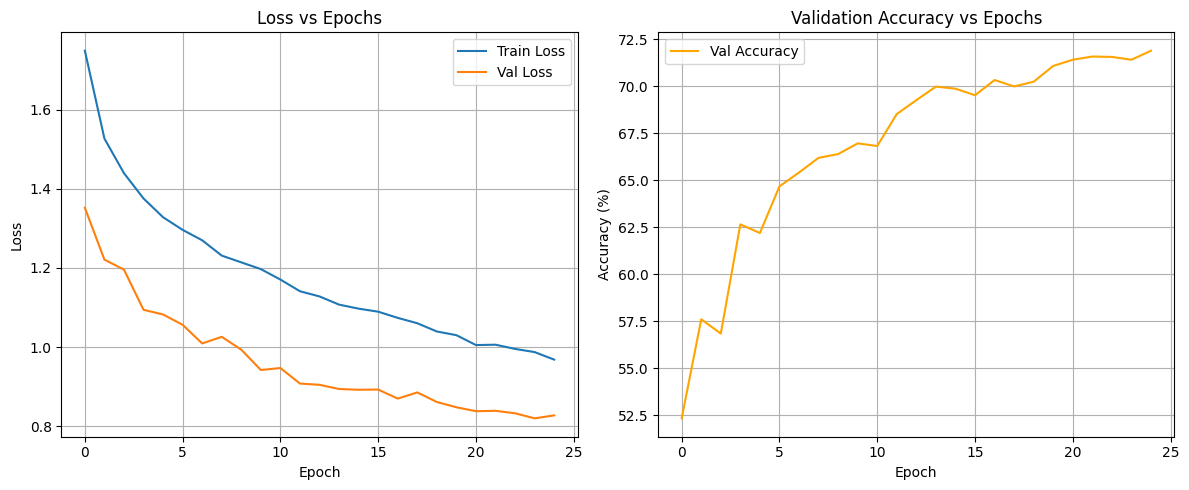

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Val Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
test_loss, test_acc = evaluate(model, testloader, criterion, device)
print(f"Final Test Accuracy (Task 1): {test_acc:.2f}%")

Final Test Accuracy (Task 1): 71.87%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8183348].


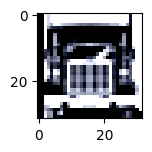

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.4953476].


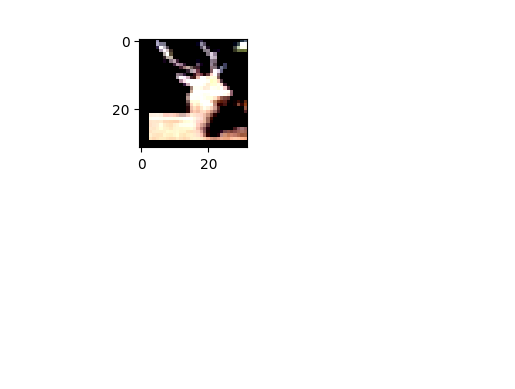

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..0.86533785].


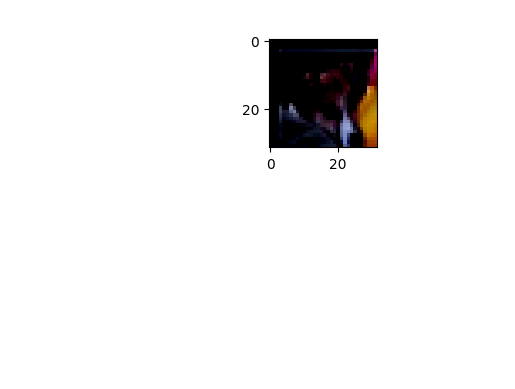

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.54976106..1.1842504].


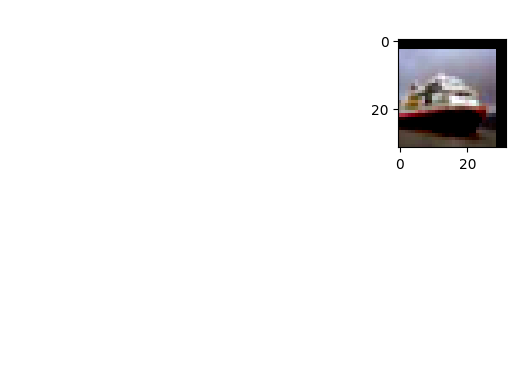

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.56914604..1.7207834].


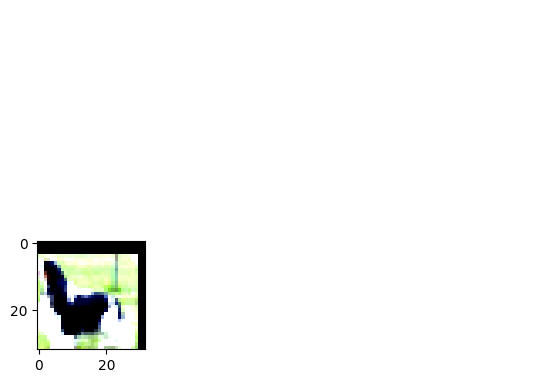

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8085796].


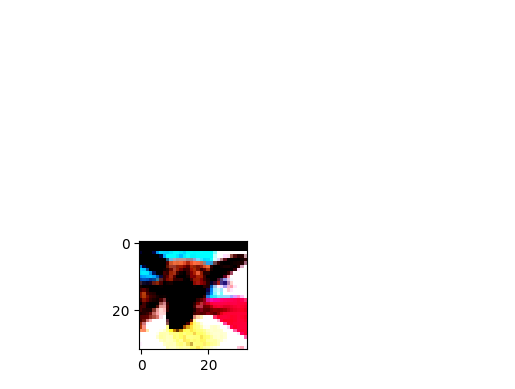

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.65637815..1.3793533].


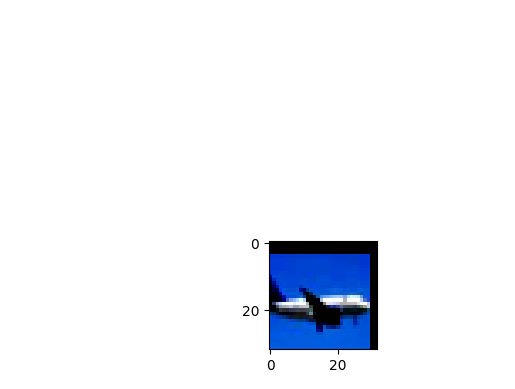

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


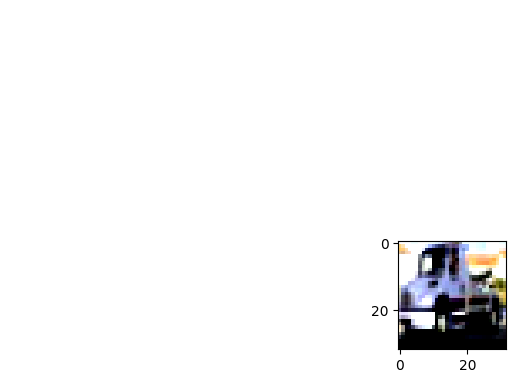

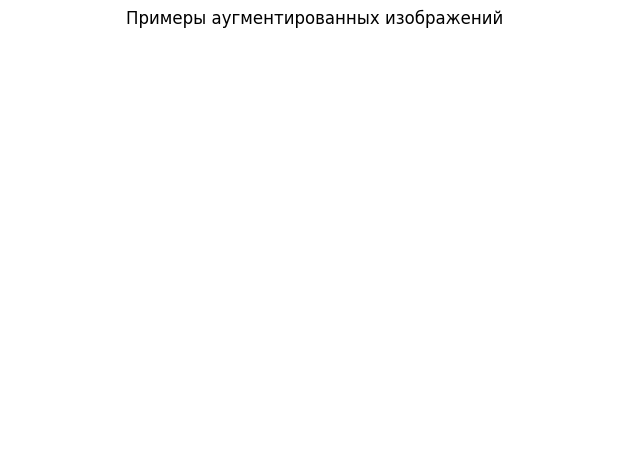

In [9]:
# Обоснование выбора аугментаций:
# 1. RandomHorizontalFlip: Объекты (машины, животные) в CIFAR-10 инвариантны к горизонтальному отражению.
#    Это удваивает разнообразие данных без изменения семантики класса.
# 2. ColorJitter: Изменение яркости/контраста делает модель устойчивее к разному освещению и условиям съемки.
# 3. RandomCrop: Случайные кропы с паддингом учат модель распознавать объекты по частям и игнорировать фон.

# Создание пайплайна аугментаций для обучения
transform_train_aug = transforms.Compose([
    # С вероятностью 0.5 зеркально отражает изображение по горизонтали
    # p=0.5: баланс между разнообразием и сохранением исходных данных
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Случайный кроп 32x32 с предварительным паддингом в 4 пикселя
    # 32: целевой размер выхода (совпадает с размером CIFAR-10)
    # padding=4: добавляет рамку из нулей, затем случайно вырезается 32x32
    # Это создает вариативность в позиционировании объекта в кадре
    transforms.RandomCrop(32, padding=4),
    
    # Случайное изменение цветовых характеристик
    # brightness=0.2: яркость меняется в диапазоне [0.8, 1.2] от оригинала
    # contrast=0.2: контраст меняется в диапазоне [0.8, 1.2]
    # Можно добавить параметры saturation и hue для цветных изображений
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    # Конвертация в тензор (должна идти ПОСЛЕ аугментаций, работающих с PIL)
    transforms.ToTensor(),
    
    # Нормализация (должна идти ПОСЛЕ ToTensor)
    transforms.Normalize(mean, std)
])

# Обновление датасета для обучения с аугментацией
# Важно: аугментации применяются "на лету" при каждой итерации DataLoader,
# поэтому одно и то же изображение будет разным в разных эпохах
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                            download=True, transform=transform_train_aug)

# Применяем то же разбиение на train/val (те же индексы), чтобы сравнение было корректным
# Валидационная выборка НЕ аугментируется, чтобы оценка качества была объективной
trainset_aug = Subset(trainset_aug, train_indices)

# Создаем новый DataLoader с аугментированным датасетом
# shuffle=True: важен для аугментаций, чтобы модель не видела одинаковые трансформации подряд
trainloader_aug = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=2)

# === Визуализация аугментированных изображений ===
# Получаем итератор из DataLoader
dataiter_aug = iter(trainloader_aug)
# Берем один батч изображений (8+ изображений для примера)
# _ означает, что лейблы нам не нужны для визуализации
images_aug, _ = next(dataiter_aug)

# Настройка фигуры для отображения
# figsize=(15, 3): широкая панель для 8 изображений в ряд
plt.figure(figsize=(15, 3))

# Цикл для отображения первых 8 изображений из батча
for i in range(8):
    plt.subplot(2, 4, i+1)  # 2 строки, 4 столбца, позиция i+1
    # Функция imshow (должна быть определена ранее) денормализует и показывает изображение
    imshow(images_aug[i])
    plt.axis('off')  # Отключаем оси для чистоты отображения
    
# Заголовок для всей фигуры
plt.suptitle("Примеры аугментированных изображений")
# Автоматическая подгонка отступов, чтобы элементы не налезали друг на друга
plt.tight_layout()
# Отображение графика
plt.show()

In [10]:
class ImprovedCNN(nn.Module):
    """
    Улучшенная архитектура CNN с следующими изменениями:
    - Глубже (3 сверточных блока вместо 2)
    - Больше фильтров (64->128->256 вместо 32->64)
    - LeakyReLU вместо ReLU (проблема "мёртвых нейронов")
    - Dropout после каждого сверточного блока
    - BatchNorm в полностью связном слое
    - AdamW + Weight Decay для регуляризации
    - Learning Rate Scheduler для адаптивного обучения
    """
    
    def __init__(self, num_classes=10):
        super(ImprovedCNN, self).__init__()
        
        # === БЛОК 1 ===
        # 3 входных канала (RGB) -> 64 выходных канала
        # kernel_size=3, padding=1 сохраняет размер пространственной размерности
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)  # Нормализация по 64 каналам
        # LeakyReLU вместо ReLU: пропускает небольшой градиент при x < 0
        # negative_slope=0.01: коэффициент наклона для отрицательной части
        self.relu1 = nn.LeakyReLU(negative_slope=0.01)
        self.pool1 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        self.dropout1 = nn.Dropout2d(0.3)  # Dropout для сверточных карт (p=0.3)
        
        # === БЛОК 2 ===
        # 64 -> 128 каналов (увеличиваем глубину признаков)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.LeakyReLU(negative_slope=0.01)
        self.pool2 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        self.dropout2 = nn.Dropout2d(0.3)  # Регуляризация после 2-го блока
        
        # === БЛОК 3 (НОВЫЙ) ===
        # 128 -> 256 каналов (ещё более абстрактные признаки)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.LeakyReLU(negative_slope=0.01)
        self.pool3 = nn.MaxPool2d(2, 2)  # 8x8 -> 4x4
        # Dropout в 3-м блоке не добавлен, чтобы не терять слишком много информации
        
        # === Classifier (Полносвязные слои) ===
        # Расчет размера входа:
        # 32 -> 16 (pool1) -> 8 (pool2) -> 4 (pool3)
        # Каналов: 256
        # Итого: 256 * 4 * 4 = 4096 элементов
        self.fc1 = nn.Linear(256 * 4 * 4, 256)  # Проекция в 256-мерное пространство
        self.bn_fc = nn.BatchNorm1d(256)  # BatchNorm для 1D-тензора (после flatten)
        self.relu_fc = nn.ReLU()  
        self.dropout_fc = nn.Dropout(0.5)  # Dropout перед финальным слоем (p=0.5)
        self.fc2 = nn.Linear(256, num_classes)  # Выходной слой (256 -> 10 классов)
        
    def forward(self, x):
        """
        Прямой проход с компактной записью (цепочкой вызовов)
        """
        # Блок 1
        x = self.dropout1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
        
        # Блок 2
        x = self.dropout2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
        
        # Блок 3 (без dropout)
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        
        # Flatten: [Batch, 256, 4, 4] -> [Batch, 4096]
        x = x.view(-1, 256 * 4 * 4)
        
        # Classifier
        x = self.dropout_fc(self.relu_fc(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        
        return x  # Логиты (без Softmax)

# Создание и перенос модели на устройство
model_imp = ImprovedCNN(num_classes=10).to(device)

# === Оптимизатор и Планировщик ===
# AdamW вместо Adam:
# - AdamW корректно разделяет weight decay и градиентный спуск
# - weight_decay=1e-4: L2-регуляризация для борьбы с переобучением
# - lr=0.001: начальная скорость обучения
optimizer_imp = optim.AdamW(model_imp.parameters(), lr=0.001, weight_decay=1e-4)

# ReduceLROnPlateau: уменьшает LR, когда метрика перестает улучшаться
# mode='max': отслеживаем максимальную точность (val_acc)
# patience=3: ждём 3 эпохи без улучшений перед уменьшением LR
# factor=0.5: уменьшаем LR в 2 раза (lr = lr * 0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_imp, mode='max', patience=3, factor=0.5)

# === Обучение улучшенной модели ===
num_epochs_imp = 30  # Увеличено с 25 до 30 (более глубокой модели нужно больше времени)
train_losses_imp = []  # История потерь на обучении
val_accs_imp = []      # История точности на валидации

best_val_acc_imp = 0.0  # Лучшая точность на валидации
best_model_wts_imp = copy.deepcopy(model_imp.state_dict())  # Веса лучшей модели

print("Start Training (Task 2 - Improved)...")

for epoch in range(num_epochs_imp):
    # Train с АУГМЕНТАЦИЯМИ (trainloader_aug вместо trainloader)
    # Аугментации значительно улучшают обобщающую способность
    train_loss = train_epoch(model_imp, trainloader_aug, optimizer_imp, criterion, device)
    train_losses_imp.append(train_loss)
    
    # Validate (без аугментаций, объективная оценка)
    val_loss, val_acc = evaluate(model_imp, valloader, criterion, device)
    val_accs_imp.append(val_acc)
    
    # Шаг планировщика learning rate
    # Передаем val_acc, так как mode='max' (отслеживаем максимум)
    scheduler.step(val_acc)
    
    # Сохранение лучшей модели
    if val_acc > best_val_acc_imp:
        best_val_acc_imp = val_acc
        best_model_wts_imp = copy.deepcopy(model_imp.state_dict())
        
    # Логирование
    print(f"Epoch {epoch+1}/{num_epochs_imp} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%")

# Загрузка весов лучшей модели (откат к пику валидации)
model_imp.load_state_dict(best_model_wts_imp)

Start Training (Task 2 - Improved)...
Epoch 1/30 | Train Loss: 1.6770 | Val Acc: 56.61%
Epoch 2/30 | Train Loss: 1.3735 | Val Acc: 65.12%
Epoch 3/30 | Train Loss: 1.2368 | Val Acc: 66.93%
Epoch 4/30 | Train Loss: 1.1538 | Val Acc: 69.91%
Epoch 5/30 | Train Loss: 1.0889 | Val Acc: 72.44%
Epoch 6/30 | Train Loss: 1.0357 | Val Acc: 73.35%
Epoch 7/30 | Train Loss: 1.0040 | Val Acc: 74.89%
Epoch 8/30 | Train Loss: 0.9690 | Val Acc: 76.23%
Epoch 9/30 | Train Loss: 0.9386 | Val Acc: 75.74%
Epoch 10/30 | Train Loss: 0.9128 | Val Acc: 77.81%
Epoch 11/30 | Train Loss: 0.8770 | Val Acc: 77.97%
Epoch 12/30 | Train Loss: 0.8646 | Val Acc: 78.90%
Epoch 13/30 | Train Loss: 0.8474 | Val Acc: 78.51%
Epoch 14/30 | Train Loss: 0.8235 | Val Acc: 79.24%
Epoch 15/30 | Train Loss: 0.8074 | Val Acc: 79.69%
Epoch 16/30 | Train Loss: 0.7921 | Val Acc: 80.30%
Epoch 17/30 | Train Loss: 0.7794 | Val Acc: 80.20%
Epoch 18/30 | Train Loss: 0.7658 | Val Acc: 81.15%
Epoch 19/30 | Train Loss: 0.7532 | Val Acc: 81.80%
Ep

<All keys matched successfully>

In [11]:
test_loss_imp, test_acc_imp = evaluate(model_imp, testloader, criterion, device)
print(f"Final Test Accuracy (Task 2): {test_acc_imp:.2f}%")

Final Test Accuracy (Task 2): 83.24%
